In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [7]:
np.random.seed(42)

n = 500

age = np.random.randint(18, 60, n)
income = np.random.randint(20000, 150000, n)
spending_score = np.random.randint(1, 101, n)
previous_purchases = np.random.randint(0, 21, n)

purchase_score = (
    0.02 * income
    + 2 * spending_score
    + 50 * previous_purchases
    - 100 * age
)

purchase = (purchase_score > np.median(purchase_score)).astype(int)

df = pd.DataFrame({
    "Age": age,
    "Income": income,
    "SpendingScore": spending_score,
    "PreviousPurchases": previous_purchases,
    "Purchase": purchase
})

df.head()


,Age,Income,SpendingScore,PreviousPurchases,Purchase
0,56,81476,68,20,0
1,46,64811,10,10,0
2,32,56208,67,7,1
3,25,40150,18,10,1
4,38,91180,100,3,1


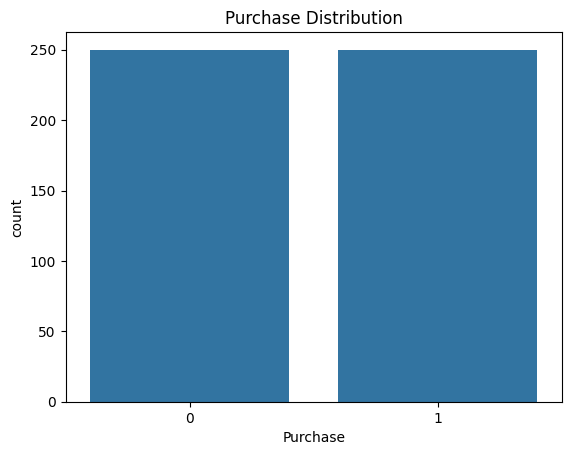

In [8]:
sns.countplot(x="Purchase", data=df)

plt.title("Purchase Distribution")
plt.show()

In [ ]:
sns.scatterplot(
    x="Income",
    y="SpendingScore",
    hue="Purchase",
    data=df
)

plt.title("Income vs Spending Score")
plt.show()

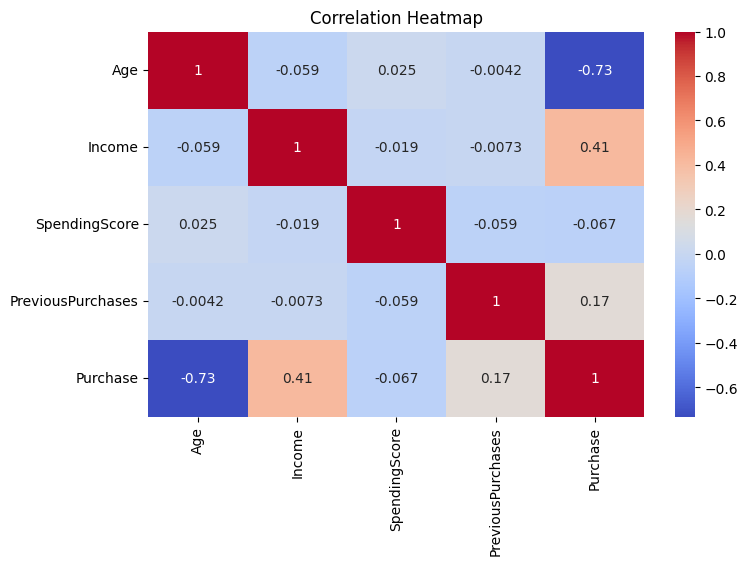

In [10]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
X = df.drop("Purchase", axis=1)

y = df["Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [16]:
y_pred = knn.predict(X_test_scaled)